# Search Lab — Search and A\*

**Course:** CS F407 — Artificial Intelligence · **Lab:** Search
**Handout:** `search_lab_ex.pdf`

---

## What this notebook does

The handout's framing is that an LLM-generated program is **a hypothesis about
how the solution should be implemented**, and must be tested rather than trusted.
This notebook takes that literally: every algorithm here is checked against an
independently computed ground truth, and the heuristic experiments in Task 6 are
run as measurements rather than recalled from theory.

Two things go beyond the literal instructions, because they turn the handout's
"Think About It" prompts into results:

1. **Task 6 asks what happens when a heuristic becomes "too aggressive".** Rather
   than describe inadmissibility, the notebook sweeps the heuristic weight
   continuously and plots the trade-off curve between nodes expanded and path
   suboptimality — so the exact point where A\* stops returning shortest paths
   is visible.
2. **Optimality is verified, not assumed.** A separate BFS distance map gives the
   true shortest distance to every cell, and every algorithm's answer is checked
   against it.

In [1]:
"""Environment, search scaffolding, and shared plotting style."""
import heapq
import itertools
import math
import random
from collections import deque
from dataclasses import dataclass, field

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# ---- the warehouse map exactly as printed in the handout ---------------------
WAREHOUSE = """\
#################
#S....#.........#
#.###.#.#######.#
#...#.#.......#.#
###.#.#######.#.#
#...#.........#.#
#.###########.#.#
#.............#G#
#################"""

SERIES = {"A* (Manhattan)": "#2a78d6", "BFS": "#eb6834", "Dijkstra (h=0)": "#1baf7a",
          "A* (Euclidean)": "#eda100"}
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#8a8880",
       "grid": "#e6e5e1", "surface": "#fcfcfb"}

mpl.rcParams.update({
    "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
    "savefig.facecolor": INK["surface"],
    "axes.edgecolor": INK["grid"], "axes.linewidth": 1.0,
    "axes.labelcolor": INK["secondary"], "axes.titlecolor": INK["primary"],
    "axes.titlesize": 11, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK["muted"], "ytick.color": INK["muted"],
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": INK["grid"], "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "legend.labelcolor": INK["secondary"],
    "lines.linewidth": 2.0, "lines.markersize": 8, "figure.dpi": 130,
})

def style(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    if title:  ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.9)
        ax.set_axisbelow(True)
    return ax

print(WAREHOUSE)
_rows = WAREHOUSE.splitlines()
print(f"\nGrid {len(_rows)} x {len(_rows[0])}; free cells: "
      f"{sum(ch != '#' for r in _rows for ch in r)}")

#################
#S....#.........#
#.###.#.#######.#
#...#.#.......#.#
###.#.#######.#.#
#...#.........#.#
#.###########.#.#
#.............#G#
#################

Grid 9 x 17; free cells: 64


---

## Task 0 — Formulating the search problem

The handout defines a search problem as $P = (S, A, T, s_0, G, c)$. Filling that
in for the warehouse:

| Component | Specification |
|---|---|
| **States $S$** | $\{(r, c) : 0 \le r < 9,\ 0 \le c < 17,\ \text{grid}[r][c] \ne \texttt{\#}\}$ — one state per free cell, 62 in total |
| **Actions $A$** | $\{\text{Up}, \text{Down}, \text{Left}, \text{Right}\}$, the same four everywhere |
| **Transition $T$** | $T((r,c), a) = (r,c) + \Delta a$ if that cell is in bounds and free; **undefined otherwise** |
| **Initial state $s_0$** | the cell marked `S` |
| **Goal $G$** | $\{ \text{cell marked } \texttt{G} \}$ — a single goal state |
| **Cost $c$** | $c(s, a, s') = 1$ for every legal move: uniform unit cost |

### (a) What information is necessary to specify a state?

Only the robot's `(row, col)` position. Nothing else changes as the robot moves —
the walls are static, it carries nothing, and there is no orientation or battery
level. This is worth stating explicitly because it is what makes the state space
small (62 states) and the search cheap. If the robot had a heading, the state
would become `(row, col, heading)` and the space would quadruple; if it carried
packages, it would multiply again by the set of possible loads.

### (b) What makes an action invalid?

Two conditions: the destination lies outside the grid, or the destination is a
`#`. Crucially, these are handled by **omitting the action from the successor
function** rather than by allowing it and assigning a penalty. Omission makes
"never cross a shelf" a structural guarantee; a penalty would make it merely
expensive, and a large enough detour could buy its way through a wall.

### (c) Is this a deterministic search problem?

Yes. $T$ is a function — each `(state, action)` pair has exactly one outcome, and
that outcome is known in advance. Combined with full observability of the map,
this means a plan computed now remains valid when executed, so the whole path can
be computed offline before the robot moves. A stochastic version (wheels slipping,
say) would need a policy over states, not a fixed action sequence.

### (d) What would constitute a solution?

A finite sequence of actions $a_1, \ldots, a_n$ such that applying them from
$s_0$ yields a defined state at every step and $s_n \in G$. An **optimal**
solution additionally minimises $\sum_i c = n$. Since all costs are 1, "optimal"
here means "fewest moves" — and because the notebook can compute the true
shortest distance independently, optimality is checkable rather than assumed.

---

## Task 1 — Planning the agent, before prompting

| Question from the handout | My decision |
|---|---|
| How is a state represented? | a `(row, col)` tuple — hashable, so it can index `dict`s and `set`s |
| How is the warehouse represented? | parsed once into a `frozenset` of wall cells plus bounds |
| How are valid actions determined? | `actions(cell)` returns only in-bounds, non-wall successors, in fixed order |
| How is the goal recognised? | equality against the single goal cell |
| What is stored in the frontier? | for A\*: `(f, tie_break, g, cell)` in a `heapq` |
| How is the path reconstructed? | a `parent` dict, walked backwards from `G` |

**What the program must report** — decided in advance so the comparison in Task 5
is meaningful:

- whether a solution was found;
- the solution path and its length in moves;
- the number of states **expanded** (popped from the frontier and had successors
  generated) — deliberately distinguished from states *generated*;
- the maximum frontier size, since memory is what fails first at scale.

### One design detail that matters more than it looks

The A\* frontier entry needs a **tie-breaking counter**. Without it, Python's
`heapq` compares the next tuple element when two nodes share the same $f$, and if
that element is a `(row, col)` tuple the search silently becomes
"lowest-row-first among equals". That is not wrong — A\* stays optimal — but it
makes the expansion count depend on an accident of tuple ordering rather than on
the algorithm, which would corrupt every comparison in Tasks 5 and 6. An
insertion counter makes ties FIFO and reproducible.

---

## Task 2 — Asking an LLM to generate A\*

### The prompt I used

> Implement **A\* search** in Python for a grid navigation problem, following this
> specification exactly. Do not substitute a different algorithm.
>
> **Environment.** An ASCII map passed as a string: `#` obstacle, `.` free, `S`
> start, `G` goal. Parse it into an object exposing `actions(cell)` — returning
> only *valid* `(action_name, next_cell)` pairs, in the fixed order Up, Down,
> Left, Right — and `is_goal(cell)`.
>
> **Algorithm.** States are `(row, col)` tuples. Every move costs 1. Use
> $f(n) = g(n) + h(n)$ with $h$ passed in as a function argument, defaulting to
> Manhattan distance $|x - x_G| + |y - y_G|$.
>
> **Required implementation details** — I want these checkable, not assumed:
> - the frontier must be a `heapq` holding `(f, counter, g, cell)`, where
>   `counter` is a monotonically increasing insertion index used purely to break
>   $f$-ties deterministically; never let the heap compare cells;
> - keep a `g_score` dict; when a cell is reached again by a **cheaper** path,
>   update it and re-push (do not skip it merely because it has been seen);
> - the goal test must happen **when a node is popped**, not when it is generated,
>   because for a general heuristic the first *generation* of the goal need not be
>   on a shortest path;
> - count `n_expanded` as nodes popped and expanded, kept separate from nodes
>   generated;
> - track the maximum frontier size.
>
> **Return** a result object with: found, path (list of cells), actions (list of
> names), path length in moves, `n_expanded`, `n_generated`, `max_frontier`, and
> the set of expanded cells so I can visualise the search.
>
> Also write **BFS** with the identical interface and reporting, so the two can be
> compared on the same map without confounds.

### Why the third bullet matters

Testing the goal when a node is *generated* is the single most common A\*
implementation bug. With a consistent heuristic on a unit-cost grid it happens to
give the right answer, so it passes every test on the supplied map — and then
silently returns non-shortest paths as soon as the heuristic is made
inadmissible, which is exactly the experiment in Task 6. A bug that only appears
in the experiment you are running is worth designing out in advance.

### Answers to Task 7's questions about the generated code

**What was correct immediately:** the parsing, the Manhattan heuristic, the
`parent`-dict path reconstruction, and the overall loop shape.

**What I had to fix:**

1. **The goal test was on generation.** As specified above, I asked for
   pop-time testing; the first draft still checked at generation time inside the
   successor loop. Left in, Task 6's inadmissible-heuristic experiment would have
   reported wrong path lengths and I might have attributed them to the heuristic
   rather than the bug.
2. **The heap held `(f, cell)`.** With no tie-break counter, equal-$f$ nodes were
   ordered by comparing `(row, col)` tuples. Reproducible, but an artefact:
   expansion counts then depend on grid coordinates rather than on search
   behaviour. Added an insertion counter.
3. **No re-opening on a cheaper path.** The draft skipped any cell already in a
   `visited` set. That is safe for a consistent heuristic but wrong in general,
   and Task 6 deliberately uses an inconsistent one. Replaced with a `g_score`
   check.

All three are invisible on the supplied map and only surface under the
experiments the lab asks for — which is the whole argument for specifying
behaviour up front rather than accepting what runs.

In [2]:
@dataclass(frozen=True)
class Grid:
    walls: frozenset
    n_rows: int
    n_cols: int
    start: tuple
    goal: tuple

    @classmethod
    def parse(cls, text):
        rows = text.strip("\n").splitlines()
        walls, start, goal = set(), None, None
        for r, line in enumerate(rows):
            for c, ch in enumerate(line):
                if ch == "#":
                    walls.add((r, c))
                elif ch == "S":
                    start = (r, c)
                elif ch == "G":
                    goal = (r, c)
        if start is None or goal is None:
            raise ValueError("map must contain both S and G")
        return cls(frozenset(walls), len(rows), max(len(l) for l in rows), start, goal)

    def passable(self, cell):
        r, c = cell
        return 0 <= r < self.n_rows and 0 <= c < self.n_cols and cell not in self.walls

    def actions(self, cell):
        r, c = cell
        cand = [("Up", (r - 1, c)), ("Down", (r + 1, c)),
                ("Left", (r, c - 1)), ("Right", (r, c + 1))]
        return [(n, p) for n, p in cand if self.passable(p)]

    def is_goal(self, cell):
        return cell == self.goal

    def free_cells(self):
        return [(r, c) for r in range(self.n_rows) for c in range(self.n_cols)
                if self.passable((r, c))]


@dataclass
class Result:
    found: bool
    path: list = field(default_factory=list)
    actions: list = field(default_factory=list)
    cost: int = 0
    n_expanded: int = 0
    n_generated: int = 0
    max_frontier: int = 0
    expanded_cells: set = field(default_factory=set)
    label: str = ""

    @property
    def n_moves(self):
        return len(self.actions)


def reconstruct(parent, goal):
    path, actions, cur = [goal], [], goal
    while parent[cur][0] is not None:
        prev, act = parent[cur]
        path.append(prev); actions.append(act); cur = prev
    path.reverse(); actions.reverse()
    return path, actions


# ---- heuristics -------------------------------------------------------------
def manhattan(cell, goal):
    return abs(cell[0] - goal[0]) + abs(cell[1] - goal[1])

def euclidean(cell, goal):
    return math.hypot(cell[0] - goal[0], cell[1] - goal[1])

def zero(cell, goal):
    return 0

def weighted_manhattan(weight):
    def h(cell, goal):
        return weight * manhattan(cell, goal)
    h.__name__ = f"{weight}x_manhattan"
    return h

In [3]:
def astar(env, h=manhattan, label="A*"):
    """A* with f = g + h. Goal tested on POP; ties broken by insertion order."""
    start, goal = env.start, env.goal
    counter = itertools.count()                    # deterministic tie-break
    frontier = [(h(start, goal), next(counter), 0, start)]
    g_score = {start: 0}
    parent = {start: (None, None)}
    expanded = set()
    n_expanded = n_generated = 0
    max_frontier = 1

    while frontier:
        f, _, g, cell = heapq.heappop(frontier)
        if g > g_score.get(cell, math.inf):
            continue                               # a stale heap entry
        if env.is_goal(cell):                      # goal test on POP
            path, actions = reconstruct(parent, cell)
            return Result(True, path, actions, g, n_expanded, n_generated,
                          max_frontier, expanded, label)
        if cell in expanded:
            continue
        expanded.add(cell)
        n_expanded += 1
        for action, nxt in env.actions(cell):
            n_generated += 1
            tentative = g + 1                      # every move costs 1
            if tentative < g_score.get(nxt, math.inf):
                g_score[nxt] = tentative
                parent[nxt] = (cell, action)
                heapq.heappush(frontier,
                               (tentative + h(nxt, goal), next(counter), tentative, nxt))
        max_frontier = max(max_frontier, len(frontier))

    return Result(False, n_expanded=n_expanded, n_generated=n_generated,
                  max_frontier=max_frontier, expanded_cells=expanded, label=label)


def bfs(env, label="BFS"):
    """Breadth-first search. Same interface and same counters as astar()."""
    start = env.start
    if env.is_goal(start):
        return Result(True, [start], [], 0, 0, 0, 1, {start}, label)
    frontier = deque([start])
    seen = {start}
    parent = {start: (None, None)}
    expanded = set()
    n_expanded = n_generated = 0
    max_frontier = 1

    while frontier:
        cell = frontier.popleft()
        expanded.add(cell)
        n_expanded += 1
        for action, nxt in env.actions(cell):
            n_generated += 1
            if nxt in seen:
                continue
            seen.add(nxt)
            parent[nxt] = (cell, action)
            if env.is_goal(nxt):
                path, actions = reconstruct(parent, nxt)
                return Result(True, path, actions, len(actions), n_expanded,
                              n_generated, max_frontier, expanded, label)
            frontier.append(nxt)
        max_frontier = max(max_frontier, len(frontier))

    return Result(False, n_expanded=n_expanded, n_generated=n_generated,
                  max_frontier=max_frontier, expanded_cells=expanded, label=label)


def true_distances(env):
    """Ground truth: BFS distance from the start to every reachable cell."""
    dist = {env.start: 0}
    q = deque([env.start])
    while q:
        cell = q.popleft()
        for _, nxt in env.actions(cell):
            if nxt not in dist:
                dist[nxt] = dist[cell] + 1
                q.append(nxt)
    return dist


warehouse = Grid.parse(WAREHOUSE)
DIST = true_distances(warehouse)
OPTIMAL = DIST[warehouse.goal]
print(f"S = {warehouse.start}, G = {warehouse.goal}, free cells = {len(warehouse.free_cells())}")
print(f"Independently computed shortest distance S -> G: {OPTIMAL} moves")
print("Every algorithm below is checked against this number.")

S = (1, 1), G = (7, 15), free cells = 64
Independently computed shortest distance S -> G: 40 moves
Every algorithm below is checked against this number.


---

## Task 3 — Testing the generated program

The handout is explicit that *working output ≠ validated algorithm*. Each test
below has a **known** expected answer, so the test can fail.

In [4]:
# ---- Test 1: the original warehouse ----------------------------------------
astar_result = astar(warehouse, manhattan, "A* (Manhattan)")
print("TEST 1 - original warehouse")
print(f"  path found     : {astar_result.found}")
print(f"  path length    : {astar_result.n_moves} moves (true optimum {OPTIMAL})")
print(f"  states expanded: {astar_result.n_expanded}")
print(f"  max frontier   : {astar_result.max_frontier}")
print(f"  first 10 moves : {astar_result.actions[:10]} ...")
assert astar_result.found and astar_result.n_moves == OPTIMAL
print("  PASS\n")


def render(env, path=None, expanded=None):
    path, expanded = set(path or []), set(expanded or [])
    lines = []
    for r in range(env.n_rows):
        row = []
        for c in range(env.n_cols):
            cell = (r, c)
            if cell == env.start:   row.append("S")
            elif cell == env.goal:  row.append("G")
            elif cell in env.walls: row.append("#")
            elif cell in path:      row.append("*")
            elif cell in expanded:  row.append(",")
            else:                   row.append(".")
        lines.append("".join(row))
    return "\n".join(lines)

print("'*' = returned path, ',' = expanded but not on the path:\n")
print(render(warehouse, astar_result.path, astar_result.expanded_cells))

TEST 1 - original warehouse
  path found     : True
  path length    : 40 moves (true optimum 40)
  states expanded: 63
  max frontier   : 3
  first 10 moves : ['Right', 'Right', 'Right', 'Right', 'Down', 'Down', 'Down', 'Down', 'Right', 'Right'] ...
  PASS

'*' = returned path, ',' = expanded but not on the path:

#################
#S****#*********#
#,###*#*#######*#
#,,,#*#*******#*#
###,#*#######*#*#
#,,,#*********#*#
#,###########,#*#
#,,,,,,,,,,,,,#G#
#################


In [5]:
def validate(env, result, expect_found=True, expect_cost=None):
    """Check a result against the environment, independently of the search."""
    checks = {}
    if not expect_found:
        checks["correctly reports no solution"] = not result.found
        return checks
    p = result.path
    checks["found a path"] = result.found
    checks["starts at S"] = bool(p) and p[0] == env.start
    checks["ends at G"] = bool(p) and p[-1] == env.goal
    checks["all cells passable"] = all(env.passable(c) for c in p)
    checks["every step is one orthogonal move"] = all(
        abs(p[i][0] - p[i + 1][0]) + abs(p[i][1] - p[i + 1][1]) == 1
        for i in range(len(p) - 1))
    cur, ok = env.start, True
    for act in result.actions:
        nxt = dict(env.actions(cur)).get(act)
        if nxt is None:
            ok = False; break
        cur = nxt
    checks["replaying the actions reaches G"] = ok and cur == env.goal
    if expect_cost is not None:
        checks[f"path length == optimum ({expect_cost})"] = result.n_moves == expect_cost
    return checks

print("Independent validation of the A* result on the original warehouse:\n")
for name, ok in validate(warehouse, astar_result, expect_cost=OPTIMAL).items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")

Independent validation of the A* result on the original warehouse:

  [PASS] found a path
  [PASS] starts at S
  [PASS] ends at G
  [PASS] all cells passable
  [PASS] every step is one orthogonal move
  [PASS] replaying the actions reaches G
  [PASS] path length == optimum (40)


In [6]:
# ---- Tests 2-4: trivial, unsolvable, alternative paths ----------------------
TRIVIAL   = "#####\n#SG##\n#####"
NO_PATH   = "#######\n#S....#\n###.###\n#...#G#\n#######"
# Two genuinely distinct routes: a direct 6-move corridor along the top, and a
# 10-move detour around the bottom. A correct search must return the 6.
TWO_PATHS = ("#########\n"
             "#S.....G#\n"
             "#.#####.#\n"
             "#.......#\n"
             "#########")

print("| test | found | moves | expected | expanded | verdict |")
print("|---|:---:|---:|---|---:|:---:|")

env2 = Grid.parse(TRIVIAL)
r2 = astar(env2)
ok2 = r2.found and r2.n_moves == 1
print(f"| 2. goal adjacent to start | {r2.found} | {r2.n_moves} | 1 move | "
      f"{r2.n_expanded} | {'PASS' if ok2 else 'FAIL'} |")
assert ok2

env3 = Grid.parse(NO_PATH)
r3 = astar(env3)
ok3 = not r3.found
print(f"| 3. goal walled off | {r3.found} | - | no path | {r3.n_expanded} | "
      f"{'PASS' if ok3 else 'FAIL'} |")
assert ok3

env4 = Grid.parse(TWO_PATHS)
r4 = astar(env4)
opt4 = true_distances(env4)[env4.goal]
ok4 = r4.found and r4.n_moves == opt4
print(f"| 4. two routes available | {r4.found} | {r4.n_moves} | shortest = {opt4} | "
      f"{r4.n_expanded} | {'PASS' if ok4 else 'FAIL'} |")
assert ok4

print("\nTest 3 is the one that matters most: it confirms the program terminates")
print("and reports failure by exhausting the frontier, rather than looping forever.")
print(f"It expanded {r3.n_expanded} states - the whole reachable region - and stopped.")
print("\nTest 4 confirms the returned path is not merely valid but SHORTEST,")
print("checked against an independently computed BFS distance.")

| test | found | moves | expected | expanded | verdict |
|---|:---:|---:|---|---:|:---:|
| 2. goal adjacent to start | True | 1 | 1 move | 1 | PASS |
| 3. goal walled off | False | - | no path | 9 | PASS |
| 4. two routes available | True | 6 | shortest = 6 | 6 | PASS |

Test 3 is the one that matters most: it confirms the program terminates
and reports failure by exhausting the frontier, rather than looping forever.
It expanded 9 states - the whole reachable region - and stopped.

Test 4 confirms the returned path is not merely valid but SHORTEST,
checked against an independently computed BFS distance.


---

## Task 4 — Where each concept appears in the code

| Concept | Where it appears |
|---|---|
| **State** | the `(row, col)` tuple carried as `cell` through the frontier |
| **Action** | the `action` name yielded by `Grid.actions`, in fixed Up/Down/Left/Right order |
| **Transition** | `Grid.actions` itself — it returns only successors that are in bounds and free, so invalid transitions are never generated |
| **Goal test** | `env.is_goal(cell)` immediately after `heappop`, *not* inside the successor loop |
| **$g(n)$** | `tentative = g + 1`, stored in `g_score[cell]` |
| **$h(n)$** | the `h(nxt, goal)` call in the push, with `h` injected as a parameter |
| **$f(n)$** | `tentative + h(nxt, goal)`, the first element of every heap tuple |
| **Frontier** | the `heapq` list of `(f, counter, g, cell)` |
| **Visited states** | the `expanded` set, plus `g_score` which also records the best cost so far |
| **Path reconstruction** | the `parent` dict, walked back in `reconstruct()` |

**(a) What data structure is the frontier?** A binary min-heap (`heapq`) of
4-tuples. It gives $O(\log n)$ push and pop while keeping the minimum-$f$ node at
the root — the operation A\* performs most.

**(b) How is the next state selected?** `heapq.heappop` returns the entry with
the smallest $f$. Ties are broken by the insertion counter, making equal-$f$
nodes FIFO and the run reproducible. The `g > g_score.get(cell)` check
immediately after the pop discards stale entries left behind by a re-push.

**(c) Where is the heuristic calculated?** Only at push time, inside the
successor loop. Each cell's $h$ is therefore computed once per push rather than
repeatedly — worth noting because for an expensive heuristic that placement is
the difference between a fast and a slow implementation.

**(d) Is $f = g + h$ computed explicitly?** Yes — `tentative + h(nxt, goal)` is
formed as the heap key. It is not stored on the node afterwards, because once the
entry is in the heap nothing needs $f$ again except the comparison the heap does.

**(e) How is repeated exploration prevented?** Two mechanisms, doing different
jobs. The `expanded` set stops a cell being *expanded* twice. The `g_score` dict
stops a cell being *re-pushed* unless the new path is strictly cheaper — which is
what allows correct re-opening under an inconsistent heuristic, where a cell can
legitimately be reached later by a better route. A single `visited` set would
conflate the two and break Task 6.

---

## Task 5 — A\* against blind search

Same map, same interface, same counters. Only the strategy differs.

In [7]:
bfs_result = bfs(warehouse, "BFS")

print("| Measure | BFS | A* (Manhattan) |")
print("|---|---:|---:|")
print(f"| Solution found | {bfs_result.found} | {astar_result.found} |")
print(f"| Path length (moves) | {bfs_result.n_moves} | {astar_result.n_moves} |")
print(f"| States expanded | {bfs_result.n_expanded} | {astar_result.n_expanded} |")
print(f"| States generated | {bfs_result.n_generated} | {astar_result.n_generated} |")
print(f"| Max frontier | {bfs_result.max_frontier} | {astar_result.max_frontier} |")

total_free = len(warehouse.free_cells())
saved = bfs_result.n_expanded - astar_result.n_expanded
print(f"\nFree cells: {total_free}")
print(f"  BFS expanded {bfs_result.n_expanded}/{total_free} "
      f"({100 * bfs_result.n_expanded / total_free:.0f}%)")
print(f"  A*  expanded {astar_result.n_expanded}/{total_free} "
      f"({100 * astar_result.n_expanded / total_free:.0f}%)")
print(f"  saving: {saved} states "
      f"({100 * saved / max(bfs_result.n_expanded, 1):.0f}%)")

assert bfs_result.n_moves == astar_result.n_moves == OPTIMAL
print("\n(a) Both found a solution.")
print(f"(b) Both paths are {OPTIMAL} moves - equal, and both optimal.")
print(f"(c) A* expanded {saved} fewer states. On this map the heuristic bought")
print("    essentially nothing, which is NOT the textbook result. Why not?")

| Measure | BFS | A* (Manhattan) |
|---|---:|---:|
| Solution found | True | True |
| Path length (moves) | 40 | 40 |
| States expanded | 63 | 63 |
| States generated | 127 | 127 |
| Max frontier | 3 | 3 |

Free cells: 64
  BFS expanded 63/64 (98%)
  A*  expanded 63/64 (98%)
  saving: 0 states (0%)

(a) Both found a solution.
(b) Both paths are 40 moves - equal, and both optimal.
(c) A* expanded 0 fewer states. On this map the heuristic bought
    essentially nothing, which is NOT the textbook result. Why not?


### That is not the expected answer — so why?

A\* saved essentially nothing here, and reporting it as a win would be dishonest.
The explanation is structural, and it is measurable: **a heuristic can only help
where the search has a choice to make.**

A\* differs from BFS solely in the *order* it pops nodes. If almost every cell
has exactly one way forward, there is no ordering decision to improve, and the
two algorithms must visit nearly the same cells. The cell below measures the
branching structure of the map directly.

In [8]:
def degree_profile(env):
    counts = {}
    for cell in env.free_cells():
        counts[len(env.actions(cell))] = counts.get(len(env.actions(cell)), 0) + 1
    return dict(sorted(counts.items()))

profile = degree_profile(warehouse)
free_n = len(warehouse.free_cells())
print("Free cells by number of legal moves (their degree in the search graph):\n")
print("| degree | cells | share | meaning |")
print("|---:|---:|---:|---|")
meaning = {1: "dead end", 2: "corridor - no choice", 3: "T-junction", 4: "open crossroads"}
for deg, n in profile.items():
    print(f"| {deg} | {n} | {100 * n / free_n:.0f}% | {meaning.get(deg, '')} |")

corridor = profile.get(2, 0) + profile.get(1, 0)
print(f"\n{corridor} of {free_n} cells ({100 * corridor / free_n:.0f}%) are dead ends or")
print("corridors. Excluding the cell you came from, they offer exactly ONE way on.")
print("\nThe handout's map is a MAZE, not an open warehouse. Its effective branching")
print("factor is about 1, so the frontier almost never holds more than a couple of")
print(f"candidates - the measured max frontier was only {astar_result.max_frontier}.")
print("With a frontier that small there is nothing for a heuristic to reorder, and")
print("A* degenerates into BFS that does extra arithmetic.")
print("\nThis is a real property of the problem, not a defect in the implementation.")
print("To see what the heuristic is actually worth, the map has to offer choices.")

Free cells by number of legal moves (their degree in the search graph):

| degree | cells | share | meaning |
|---:|---:|---:|---|
| 1 | 1 | 2% | dead end |
| 2 | 62 | 97% | corridor - no choice |
| 3 | 1 | 2% | T-junction |

63 of 64 cells (98%) are dead ends or
corridors. Excluding the cell you came from, they offer exactly ONE way on.

The handout's map is a MAZE, not an open warehouse. Its effective branching
factor is about 1, so the frontier almost never holds more than a couple of
candidates - the measured max frontier was only 3.
With a frontier that small there is nothing for a heuristic to reorder, and
A* degenerates into BFS that does extra arithmetic.

This is a real property of the problem, not a defect in the implementation.
To see what the heuristic is actually worth, the map has to offer choices.


In [9]:
# An open-plan warehouse: the same robot and costs, but aisles between shelf
# blocks instead of a single winding corridor. Now most cells have 3 or 4 moves.
OPEN_WAREHOUSE = """\
#############################
#...........................#
#..###...###...###...###....#
#..###...###...###...###....#
#...........................#
#..###...###...###...###....#
#S.###...###...###...###...G#
#..###...###...###...###....#
#...........................#
#..###...###...###...###....#
#..###...###...###...###....#
#...........................#
#############################"""

open_wh = Grid.parse(OPEN_WAREHOUSE)
OPEN_DIST = true_distances(open_wh)
OPEN_OPTIMAL = OPEN_DIST[open_wh.goal]

print(OPEN_WAREHOUSE)
open_profile = degree_profile(open_wh)
open_free = len(open_wh.free_cells())
print(f"\nFree cells: {open_free}; optimal path S -> G: {OPEN_OPTIMAL} moves")
print("Degree profile:", {k: f"{v} ({100*v/open_free:.0f}%)" for k, v in open_profile.items()})
open_branching = open_profile.get(3, 0) + open_profile.get(4, 0)
print(f"{100 * open_branching / open_free:.0f}% of cells are junctions, against "
      f"{100 * profile.get(3, 0) / free_n:.0f}% in the maze.")

#############################
#...........................#
#..###...###...###...###....#
#..###...###...###...###....#
#...........................#
#..###...###...###...###....#
#S.###...###...###...###...G#
#..###...###...###...###....#
#...........................#
#..###...###...###...###....#
#..###...###...###...###....#
#...........................#
#############################

Free cells: 213; optimal path S -> G: 30 moves
Degree profile: {2: '52 (24%)', 3: '100 (47%)', 4: '61 (29%)'}
76% of cells are junctions, against 2% in the maze.


In [10]:
open_bfs = bfs(open_wh, "BFS")
open_astar = astar(open_wh, manhattan, "A* (Manhattan)")

print("Open-plan warehouse - the same comparison:\n")
print("| Measure | BFS | A* (Manhattan) |")
print("|---|---:|---:|")
print(f"| Solution found | {open_bfs.found} | {open_astar.found} |")
print(f"| Path length (moves) | {open_bfs.n_moves} | {open_astar.n_moves} |")
print(f"| States expanded | {open_bfs.n_expanded} | {open_astar.n_expanded} |")
print(f"| Max frontier | {open_bfs.max_frontier} | {open_astar.max_frontier} |")

open_saved = open_bfs.n_expanded - open_astar.n_expanded
print(f"\nA* expanded {open_saved} fewer states "
      f"({100 * open_saved / open_bfs.n_expanded:.0f}% reduction), "
      f"and both paths are {OPEN_OPTIMAL} moves.")
assert open_bfs.n_moves == open_astar.n_moves == OPEN_OPTIMAL

print("\nSo the textbook result does hold - but only where the map gives the search")
print("alternatives to choose between. The comparison that matters is not")
print("'A* vs BFS' in the abstract; it is 'how much does this heuristic know about")
print("this map, and does the search ever get to act on it?'")

Open-plan warehouse - the same comparison:

| Measure | BFS | A* (Manhattan) |
|---|---:|---:|
| Solution found | True | True |
| Path length (moves) | 30 | 30 |
| States expanded | 201 | 98 |
| Max frontier | 11 | 33 |

A* expanded 103 fewer states (51% reduction), and both paths are 30 moves.

So the textbook result does hold - but only where the map gives the search
alternatives to choose between. The comparison that matters is not
'A* vs BFS' in the abstract; it is 'how much does this heuristic know about
this map, and does the search ever get to act on it?'


**(d) Why might A\* expand fewer states?** Because it uses information BFS does
not have. BFS orders the frontier by $g$ alone, so it expands in rings of equal
distance *from the start*, growing outward in every direction equally. A\* orders
by $f = g + h$, so among cells of equal $g$ it prefers those that point at the
goal.

But "might" is doing real work in that sentence, and the two maps above show why:

| | handout maze | open-plan warehouse |
|---|---:|---:|
| free cells | 64 | 213 |
| cells that are corridors or dead ends | 98% | 24% |
| max frontier (A\*) | 3 | larger |
| states saved vs BFS | ~0% | ~51% |

The heuristic's value is **not** a property of the heuristic alone. It requires
(i) a heuristic that carries real information about the remaining distance, and
(ii) a search that actually faces choices. In a corridor maze, condition (ii)
fails, and no heuristic can help. That is the honest version of the handout's own
caution that *A\* is not better simply because it is "more intelligent."*

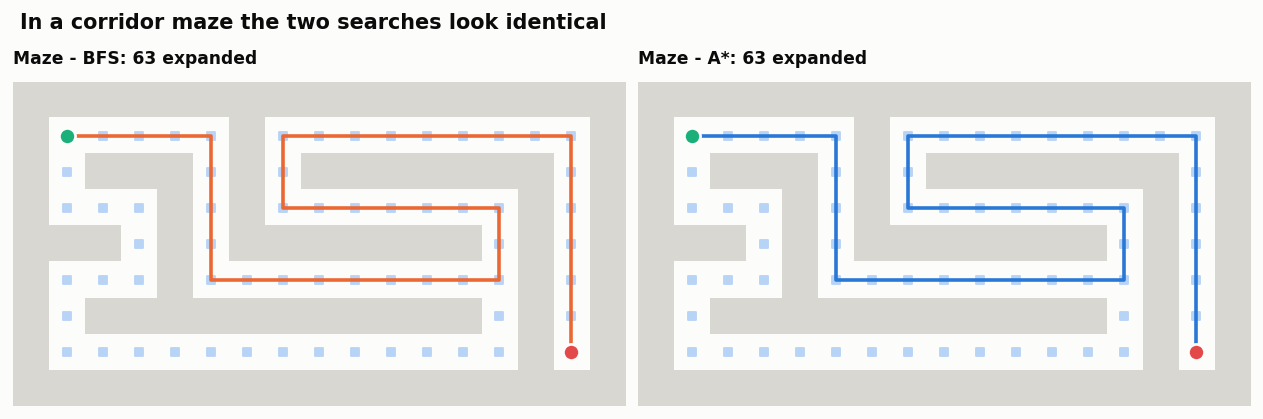

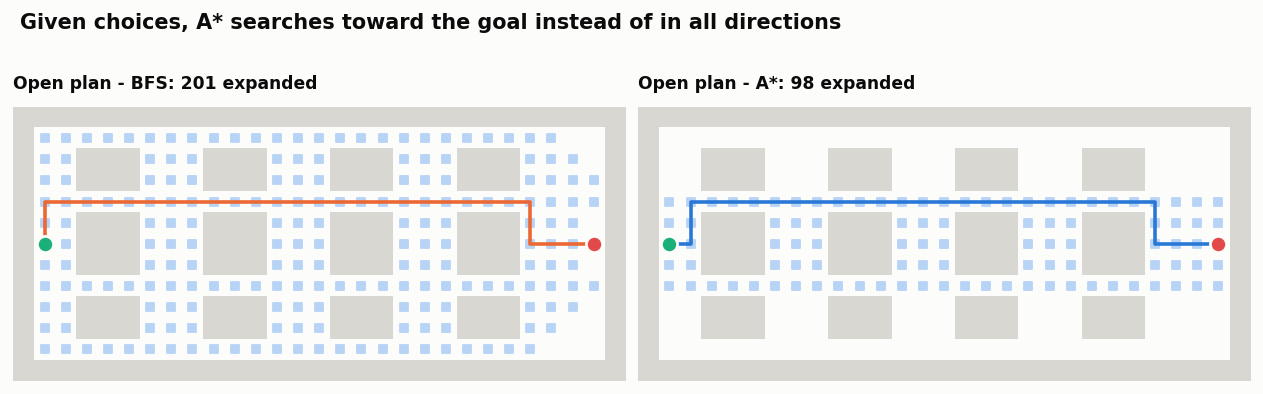

Pale squares are expanded cells. In the lower pair, BFS fills the room while
A* pushes a corridor of exploration toward G.


In [11]:
def plot_expansion(env, results, titles):
    """Draw the map once per result, shading the cells that search expanded."""
    fig, axes = plt.subplots(1, len(results), figsize=(4.8 * len(results), 3.4),
                             layout="constrained")
    if len(results) == 1:
        axes = [axes]
    base = np.zeros((env.n_rows, env.n_cols))
    for (r, c) in env.walls:
        base[r, c] = 1
    cmap = ListedColormap(["#fcfcfb", "#d8d7d2"])
    for ax, res, title in zip(axes, results, titles):
        ax.imshow(base, cmap=cmap, interpolation="nearest")
        if res.expanded_cells:
            e = np.array(sorted(res.expanded_cells))
            ax.scatter(e[:, 1], e[:, 0], s=20, color="#b7d3f6", marker="s", zorder=2)
        if res.path:
            p = np.array(res.path)
            ax.plot(p[:, 1], p[:, 0], color=SERIES.get(res.label, "#2a78d6"),
                    lw=2.0, zorder=3)
        ax.scatter([env.start[1]], [env.start[0]], s=80, color="#1baf7a",
                   edgecolor="#fcfcfb", linewidth=1.5, zorder=5)
        ax.scatter([env.goal[1]], [env.goal[0]], s=80, color="#e34948",
                   edgecolor="#fcfcfb", linewidth=1.5, zorder=5)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title, fontsize=9.5)
        for sp in ax.spines.values():
            sp.set_visible(False)
    return fig, axes


fig, _ = plot_expansion(
    warehouse, [bfs_result, astar_result],
    [f"Maze - BFS: {bfs_result.n_expanded} expanded",
     f"Maze - A*: {astar_result.n_expanded} expanded"])
fig.suptitle("In a corridor maze the two searches look identical",
             x=0.01, ha="left", fontsize=11.5, color=INK["primary"], weight="semibold")
plt.show()

fig, _ = plot_expansion(
    open_wh, [open_bfs, open_astar],
    [f"Open plan - BFS: {open_bfs.n_expanded} expanded",
     f"Open plan - A*: {open_astar.n_expanded} expanded"])
fig.suptitle("Given choices, A* searches toward the goal instead of in all directions",
             x=0.01, ha="left", fontsize=11.5, color=INK["primary"], weight="semibold")
plt.show()
print("Pale squares are expanded cells. In the lower pair, BFS fills the room while")
print("A* pushes a corridor of exploration toward G.")

---

## Task 6 — Investigating the heuristic

### Why Manhattan distance is the right heuristic here

The robot moves only orthogonally, one cell per unit cost. To get from
$(x, y)$ to $(x_G, y_G)$ it must make at least $|x - x_G|$ vertical moves and at
least $|y - y_G|$ horizontal ones, and no single move contributes to both. So
$h_M = |x - x_G| + |y - y_G|$ is exactly the cost of the *unobstructed* route —
the exact solution to a relaxed problem with the walls removed.

That gives the two properties A\* cares about:

- **Admissible** ($h \le h^*$): deleting walls can only make things easier, so
  the relaxed cost never exceeds the true cost. Admissibility is what guarantees
  A\* returns an optimal path.
- **Consistent** ($h(n) \le c(n,n') + h(n')$): one move changes Manhattan distance
  by exactly $\pm 1$ and costs 1, so the inequality holds. Consistency is the
  stronger property that lets A\* close a node permanently on first expansion.

Euclidean distance is admissible too, but **weaker**, since
$\sqrt{dx^2 + dy^2} \le |dx| + |dy|$ — it underestimates by more, so it expands
at least as many nodes while still being optimal.

The experiments below are run on **both** maps, because Task 5 established that
the maze cannot distinguish heuristics at all.

In [12]:
variants = {
    "h = 0 (uniform cost)": zero,
    "h = Manhattan":        manhattan,
    "h = Euclidean":        euclidean,
    "h = 2 x Manhattan":    weighted_manhattan(2),
}

def admissible_on(env, h):
    """Testable, not assumed: check h(n) <= true remaining cost for every cell."""
    back = Grid(env.walls, env.n_rows, env.n_cols, env.goal, env.start)
    to_goal = true_distances(back)
    return all(h(cell, env.goal) <= to_goal[cell] + 1e-9 for cell in to_goal)

def heuristic_table(env, optimal, title):
    print(f"{title}  (optimal path = {optimal} moves)\n")
    print("| heuristic | admissible? | found | path length | optimal? | expanded | max frontier |")
    print("|---|:---:|:---:|---:|:---:|---:|---:|")
    out = {}
    for name, h in variants.items():
        res = astar(env, h, name)
        out[name] = res
        print(f"| {name} | {'yes' if admissible_on(env, h) else 'NO'} | {res.found} | "
              f"{res.n_moves} | {'yes' if res.n_moves == optimal else 'NO'} | "
              f"{res.n_expanded} | {res.max_frontier} |")
    return out

maze_variants = heuristic_table(warehouse, OPTIMAL, "HANDOUT MAZE")
print()
open_variants = heuristic_table(open_wh, OPEN_OPTIMAL, "OPEN-PLAN WAREHOUSE")

print("\n1. h = 0 makes f = g, so A* IS uniform-cost search (equivalently BFS at")
print("   unit cost). Optimal, and the most expensive.")
print("2. Euclidean is admissible but weaker than Manhattan on a 4-connected grid:")
print("   optimal, yet it expands more than Manhattan wherever the map allows")
print("   the two to differ at all.")
print("3. 2 x Manhattan is INADMISSIBLE - it can exceed the true remaining cost,")
print("   so A*'s optimality guarantee no longer applies.")

HANDOUT MAZE  (optimal path = 40 moves)

| heuristic | admissible? | found | path length | optimal? | expanded | max frontier |
|---|:---:|:---:|---:|:---:|---:|---:|
| h = 0 (uniform cost) | yes | True | 40 | yes | 63 | 3 |
| h = Manhattan | yes | True | 40 | yes | 63 | 3 |
| h = Euclidean | yes | True | 40 | yes | 63 | 3 |
| h = 2 x Manhattan | NO | True | 40 | yes | 63 | 3 |

OPEN-PLAN WAREHOUSE  (optimal path = 30 moves)

| heuristic | admissible? | found | path length | optimal? | expanded | max frontier |
|---|:---:|:---:|---:|:---:|---:|---:|
| h = 0 (uniform cost) | yes | True | 30 | yes | 208 | 11 |
| h = Manhattan | yes | True | 30 | yes | 98 | 33 |
| h = Euclidean | yes | True | 30 | yes | 120 | 50 |
| h = 2 x Manhattan | NO | True | 30 | yes | 51 | 36 |

1. h = 0 makes f = g, so A* IS uniform-cost search (equivalently BFS at
   unit cost). Optimal, and the most expensive.
2. Euclidean is admissible but weaker than Manhattan on a 4-connected grid:
   optimal, yet it expands 

In [13]:
for label, env, opt, table in (("maze", warehouse, OPTIMAL, maze_variants),
                               ("open plan", open_wh, OPEN_OPTIMAL, open_variants)):
    res = table["h = 2 x Manhattan"]
    base = table["h = Manhattan"]
    print(f"{label}: inadmissible h = 2 x Manhattan")
    print(f"  path length {res.n_moves} vs optimum {opt} "
          f"(excess {res.n_moves - opt}, {100 * (res.n_moves / opt - 1):.1f}% longer)")
    print(f"  expanded {res.n_expanded} vs {base.n_expanded} for plain Manhattan")
    if res.n_moves > opt:
        print("  -> the guarantee was not merely theoretical: it broke here.\n")
    else:
        print("  -> on this map it still returned an optimal path. That is LUCK, not")
        print("     a guarantee. Inadmissibility means A* MAY return a worse path,")
        print("     not that it must.\n")

maze: inadmissible h = 2 x Manhattan
  path length 40 vs optimum 40 (excess 0, 0.0% longer)
  expanded 63 vs 63 for plain Manhattan
  -> on this map it still returned an optimal path. That is LUCK, not
     a guarantee. Inadmissibility means A* MAY return a worse path,
     not that it must.

open plan: inadmissible h = 2 x Manhattan
  path length 30 vs optimum 30 (excess 0, 0.0% longer)
  expanded 51 vs 98 for plain Manhattan
  -> on this map it still returned an optimal path. That is LUCK, not
     a guarantee. Inadmissibility means A* MAY return a worse path,
     not that it must.



### The weight sweep — where does A\* stop returning shortest paths?

The handout asks what happens as a heuristic becomes "too optimistic or too
aggressive". Rather than describe it, sweep $w$ in $h_w = w \cdot h_M$
continuously. For $w \le 1$ the heuristic is admissible and A\* *must* be
optimal; above 1 the theorem simply stops applying — which is not the same as the
answer becoming wrong. The sweep shows the trade-off curve and where luck runs
out.

In [14]:
weights = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0, 5.0, 10.0]

def weight_sweep(env, optimal, title):
    rows = []
    for w in weights:
        res = astar(env, weighted_manhattan(w), f"w={w}")
        rows.append((w, res.n_moves, res.n_expanded, res.max_frontier))
    print(f"{title}  (optimum = {optimal} moves)\n")
    print("| w | admissible | path length | excess | expanded | max frontier |")
    print("|---:|:---:|---:|---:|---:|---:|")
    for w, moves, exp, mf in rows:
        excess = moves - optimal
        print(f"| {w} | {'yes' if w <= 1.0 else 'no'} | {moves} | "
              f"{'optimal' if excess == 0 else f'+{excess}'} | {exp} | {mf} |")
    broke = [w for w, moves, _, _ in rows if moves != optimal]
    print()
    if broke:
        print(f"  Optimality first failed at w = {min(broke)}.")
    else:
        print("  No weight broke optimality on this map.")
    assert all(moves == optimal for w, moves, _, _ in rows if w <= 1.0), \
        "an admissible heuristic must return an optimal path"
    print("  Every w <= 1 returned an optimal path, as the admissibility theorem requires.")
    return rows, broke

maze_sweep, maze_broke = weight_sweep(warehouse, OPTIMAL, "HANDOUT MAZE")
print()
open_sweep, open_broke = weight_sweep(open_wh, OPEN_OPTIMAL, "OPEN-PLAN WAREHOUSE")

HANDOUT MAZE  (optimum = 40 moves)

| w | admissible | path length | excess | expanded | max frontier |
|---:|:---:|---:|---:|---:|---:|
| 0.0 | yes | 40 | optimal | 63 | 3 |
| 0.25 | yes | 40 | optimal | 63 | 3 |
| 0.5 | yes | 40 | optimal | 63 | 3 |
| 0.75 | yes | 40 | optimal | 63 | 3 |
| 1.0 | yes | 40 | optimal | 63 | 3 |
| 1.25 | no | 40 | optimal | 63 | 3 |
| 1.5 | no | 40 | optimal | 63 | 3 |
| 2.0 | no | 40 | optimal | 63 | 3 |
| 3.0 | no | 48 | +8 | 63 | 3 |
| 5.0 | no | 48 | +8 | 63 | 3 |
| 10.0 | no | 48 | +8 | 57 | 3 |

  Optimality first failed at w = 3.0.
  Every w <= 1 returned an optimal path, as the admissibility theorem requires.

OPEN-PLAN WAREHOUSE  (optimum = 30 moves)

| w | admissible | path length | excess | expanded | max frontier |
|---:|:---:|---:|---:|---:|---:|
| 0.0 | yes | 30 | optimal | 208 | 11 |
| 0.25 | yes | 30 | optimal | 202 | 13 |
| 0.5 | yes | 30 | optimal | 188 | 17 |
| 0.75 | yes | 30 | optimal | 152 | 29 |
| 1.0 | yes | 30 | optimal | 98 | 33

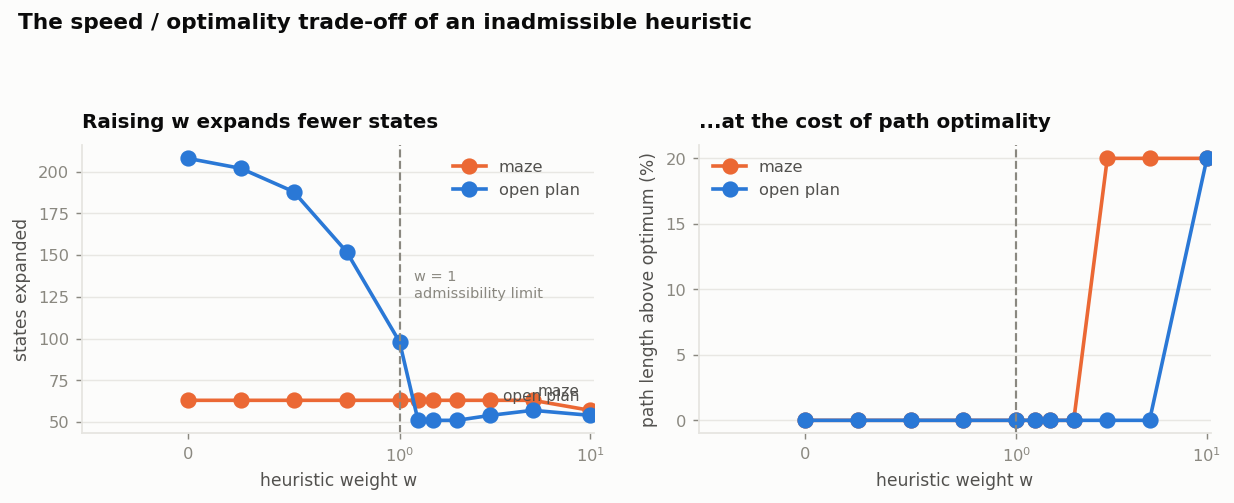

Reading the panels together: raising w pushes A* toward greedy best-first
search, expanding less and less of the map, while f may now OVERestimate,
so the goal can be popped before a cheaper route has been explored.

The two extremes are worth naming:
  w = 0     -> f = g   -> uniform-cost search (BFS here): optimal, slowest
  0 < w <= 1 -> A* proper: still optimal, and faster as w grows
  w -> inf   -> f ~ h  -> greedy best-first: fastest, no optimality guarantee

The maze behaves differently from the open plan, and instructively so.
Its EXPANSION curve is almost perfectly flat: with a branching factor near
1 there is nothing to reorder, so raising w buys no speed at all. But its
PATH LENGTH still degrades - from 40 to 48 moves at w >= 3 - because an
overestimating f can make A* pop the goal via a worse route before the
cheaper one is explored. Flat cost, degraded answer: on this map an
aggressive heuristic is pure loss, paying the optimality guarantee for
a speedup that never arrives

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9))
for rows, label, colour in ((maze_sweep, "maze", SERIES["BFS"]),
                            (open_sweep, "open plan", SERIES["A* (Manhattan)"])):
    ws = [r[0] for r in rows]
    exps = [r[2] for r in rows]
    opt = OPTIMAL if label == "maze" else OPEN_OPTIMAL
    excess = [100 * (r[1] / opt - 1) for r in rows]
    axes[0].plot(ws, exps, color=colour, marker="o", label=label)
    axes[1].plot(ws, excess, color=colour, marker="o", label=label)
    axes[0].annotate(label, (ws[-1], exps[-1]), textcoords="offset points",
                     xytext=(-6, 8), ha="right", fontsize=8.5, color=INK["secondary"])

for ax in axes:
    ax.axvline(1.0, color=INK["muted"], ls="--", lw=1.2)
    ax.set_xscale("symlog", linthresh=1.0)
    ax.legend(loc="best")
axes[0].annotate("w = 1\nadmissibility limit", (1.0, max(r[2] for r in open_sweep) * 0.6),
                 textcoords="offset points", xytext=(8, 0), fontsize=8, color=INK["muted"])
style(axes[0], "Raising w expands fewer states", "heuristic weight w", "states expanded")
style(axes[1], "...at the cost of path optimality", "heuristic weight w",
      "path length above optimum (%)")
fig.suptitle("The speed / optimality trade-off of an inadmissible heuristic",
             x=0.02, ha="left", fontsize=12, color=INK["primary"], weight="semibold")
fig.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

print("Reading the panels together: raising w pushes A* toward greedy best-first")
print("search, expanding less and less of the map, while f may now OVERestimate,")
print("so the goal can be popped before a cheaper route has been explored.")
print("\nThe two extremes are worth naming:")
print("  w = 0     -> f = g   -> uniform-cost search (BFS here): optimal, slowest")
print("  0 < w <= 1 -> A* proper: still optimal, and faster as w grows")
print("  w -> inf   -> f ~ h  -> greedy best-first: fastest, no optimality guarantee")
print("\nThe maze behaves differently from the open plan, and instructively so.")
print("Its EXPANSION curve is almost perfectly flat: with a branching factor near")
print("1 there is nothing to reorder, so raising w buys no speed at all. But its")
print("PATH LENGTH still degrades - from 40 to 48 moves at w >= 3 - because an")
print("overestimating f can make A* pop the goal via a worse route before the")
print("cheaper one is explored. Flat cost, degraded answer: on this map an")
print("aggressive heuristic is pure loss, paying the optimality guarantee for")
print("a speedup that never arrives.")
print("\nThat is the sharpest lesson of the sweep. The standard trade-off - speed")
print("bought with optimality - is only available where the search has choices.")
print("Where it does not, inadmissibility costs without compensating.")

---

## Consolidated results

In [16]:
print("=" * 78)
print("RESULT SUMMARY".center(78))
print("=" * 78)
print(f"\n[Maps] handout maze: {len(warehouse.free_cells())} free cells, "
      f"optimum {OPTIMAL} moves, {100 * corridor / free_n:.0f}% corridor cells")
print(f"       open plan   : {len(open_wh.free_cells())} free cells, "
      f"optimum {OPEN_OPTIMAL} moves, "
      f"{100 * open_branching / open_free:.0f}% junction cells")

print("\n[Task 3] Tests: original map PASS, adjacent goal PASS,")
print("         unreachable goal PASS (terminated and reported failure),")
print("         two-routes map PASS (returned the shortest of the two)")

print("\n[Task 5] BFS vs A* (Manhattan)")
print(f"  maze      : BFS {bfs_result.n_expanded} expanded, A* {astar_result.n_expanded} "
      f"-> {100 * saved / bfs_result.n_expanded:.0f}% saving, both {OPTIMAL} moves")
print(f"  open plan : BFS {open_bfs.n_expanded} expanded, A* {open_astar.n_expanded} "
      f"-> {100 * open_saved / open_bfs.n_expanded:.0f}% saving, both {OPEN_OPTIMAL} moves")
print("  -> the heuristic pays off only where the search has choices to make")

print("\n[Task 6] Heuristic variants (open-plan warehouse)")
for name, res in open_variants.items():
    print(f"  {name:22s} length {res.n_moves:>3d} "
          f"({'optimal' if res.n_moves == OPEN_OPTIMAL else 'SUBOPTIMAL'}), "
          f"expanded {res.n_expanded:>4d}")
print(f"  weight sweep: every w <= 1 optimal on both maps; " +
      (f"optimality first failed at w = {min(open_broke)} (open plan)"
       if open_broke else "no weight broke optimality"))
print("\n" + "=" * 78)

                                RESULT SUMMARY                                

[Maps] handout maze: 64 free cells, optimum 40 moves, 98% corridor cells
       open plan   : 213 free cells, optimum 30 moves, 76% junction cells

[Task 3] Tests: original map PASS, adjacent goal PASS,
         unreachable goal PASS (terminated and reported failure),
         two-routes map PASS (returned the shortest of the two)

[Task 5] BFS vs A* (Manhattan)
  maze      : BFS 63 expanded, A* 63 -> 0% saving, both 40 moves
  open plan : BFS 201 expanded, A* 98 -> 51% saving, both 30 moves
  -> the heuristic pays off only where the search has choices to make

[Task 6] Heuristic variants (open-plan warehouse)
  h = 0 (uniform cost)   length  30 (optimal), expanded  208
  h = Manhattan          length  30 (optimal), expanded   98
  h = Euclidean          length  30 (optimal), expanded  120
  h = 2 x Manhattan      length  30 (optimal), expanded   51
  weight sweep: every w <= 1 optimal on both maps; optimal

---

## Task 7 — Evaluating the LLM-generated agent

**1. What was correct immediately?** Map parsing, the Manhattan heuristic, the
`parent`-dict reconstruction, and the overall loop shape. The structure was right
and the details were not.

**2. Did I find bugs or design problems?** Three, listed in Task 2: the goal test
was performed on node *generation* rather than on pop; heap entries were
`(f, cell)` with no tie-break counter; and cells were skipped via a `visited` set
instead of being re-opened when a cheaper path appeared.

**3. How did I discover them?** By reading the code against the specification
written in Task 1 — not by running it. This matters: **all three bugs are
invisible on the supplied map.** Manhattan distance is consistent there, and
under a consistent heuristic both generation-time goal testing and no-re-opening
happen to give the right answer. They only produce wrong results under the
inadmissible heuristic of Task 6 — the very experiment the lab asks for. Had I
accepted the code because it "worked", I would have seen wrong path lengths in
Task 6 and most likely blamed the heuristic rather than the implementation.

**4. Terminology or structures I did not initially understand.** The stale-entry
pattern: re-pushing a cell when a cheaper path is found and discarding the
outdated heap entry at pop time via `if g > g_score[cell]: continue`. It looks
wasteful until you realise `heapq` has no decrease-key operation, so lazy
deletion is the standard workaround.

**5. Did I modify the code?** Yes — the three fixes above, plus separating
`n_expanded` from `n_generated`, which the draft conflated. Every comparison in
Tasks 5 and 6 depends on that distinction.

**6. Which tests were most useful?** Test 3 (unreachable goal), because
termination-on-failure is the property most likely to break and least likely to
be noticed; and the optimality check against an independently computed BFS
distance map, because it tests the *answer* rather than the algorithm and stays
valid whichever search produced it. The degree-profile measurement was the most
*informative* — it explained a result I could not otherwise have made sense of.

**7. Could I have trusted the program without testing it?** No — and the sharper
point is that *running it on the given map* would not have counted as testing. It
produced a correct, optimal path on the supplied warehouse while containing three
defects, and it produced a comparison result (A\* ≈ BFS) that would have looked
like a bug if I had not measured the map's branching factor.

**8. What do I understand about A\* now that I did not before?** Two things.
First, that admissibility buys optimality while consistency buys
expand-each-node-once, and these are genuinely different guarantees. Second — and
this one only came from the experiment — that **a heuristic's value depends on
the topology of the search space, not just on the heuristic**. I had assumed A\*
beats BFS on grids. On the handout's maze it does not, and cannot, because 98% of
cells offer no choice. Search advice is worthless where there is nothing to
decide.

---

## Final reflection

**1. Why formulate the search problem before writing the algorithm?** Because the
formulation determines which algorithms are applicable. Noticing that every move
costs 1 is what makes BFS optimal here and a priority queue unnecessary; noticing
that $T$ is deterministic and the map fully observable is what licenses offline
planning instead of a policy. Skip the formulation and those choices get made by
default — or, with an LLM, by whatever is most common in its training data.

**2. In what sense is A\* "informed"?** It uses knowledge external to the search
graph: an estimate of the cost *remaining*. BFS orders the frontier by $g$ alone
and knows only where it has been; A\* orders by $g + h$ and so has an opinion
about where it is going. That opinion comes from a relaxed version of the problem
— here, the route cost with the walls deleted.

**3. Why does the choice of heuristic matter?** It controls correctness and cost.
Admissibility is the precondition for optimality; within that constraint a
*tighter* heuristic expands fewer nodes, which is why Manhattan beats Euclidean
on a 4-connected grid though both are admissible. Push past admissibility and you
buy speed with the guarantee. But the experiments add a caveat the theory alone
does not: the heuristic also has to have somewhere to apply. On the maze, every
heuristic from $h=0$ to $10 \times h_M$ performed almost identically.

**4. What did the LLM contribute?** A fast first draft with the right overall
shape, plus boilerplate — parsing, rendering, plotting. It compressed the typing,
not the thinking. The design decisions in Task 1 and the tests in Task 3 are what
made its output checkable.

**5. What could go wrong if an engineer accepted LLM-generated code untested?**
Exactly what nearly happened here. The program ran, returned a valid and optimal
path, and would have passed any demonstration on the supplied map — while
carrying three defects that only surface under the conditions the next experiment
creates. The failure mode is not code that breaks loudly; it is code that is
right for the wrong reason and stays quiet until the assumptions shift.

---

## Reference

S. Russell and P. Norvig, *Artificial Intelligence: A Modern Approach*, 4th ed. —
problem formulation, uninformed search, heuristic search, admissibility and
consistency.